In [1]:
%pip install numpy pandas matplotlib seaborn scikit-learn joblib --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# === Imports principaux pour tout le notebook ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
import joblib
import re
from datetime import datetime, timedelta
from sklearn import __version__ as sklearn_version
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay)

warnings.filterwarnings('ignore')
%matplotlib inline

print('=== Versions utilisées ===')
print(f'Python  : {__import__("sys").version[:6]}')
print(f'pandas  : {pd.__version__}')
print(f'numpy   : {np.__version__}')
print(f'matplot : {matplotlib.__version__}')
print(f'seaborn : {sns.__version__}')
print(f'sklearn : {sklearn_version}')
print(f'joblib  : {joblib.__version__}')
print('Imports OK')


=== Versions utilisées ===
Python  : 3.12.1
pandas  : 3.0.2
numpy   : 2.4.4
matplot : 3.10.8
seaborn : 0.13.2
sklearn : 1.8.0
joblib  : 1.5.3
Imports OK


# Web Application Firewall (WAF) intelligent basé sur le Machine Learning

## Introduction
Ce notebook présente la conception d'un WAF intelligent capable de détecter les requêtes web malicieuses à l'aide de techniques de machine learning.

### Contexte
La sécurité des applications web est un enjeu majeur. Un WAF permet de protéger les sites contre les attaques courantes (injections, scans, etc.).

### Objectifs
- Détecter automatiquement les requêtes malicieuses.
- Utiliser un jeu de données synthétique représentatif du trafic web.
- Comparer plusieurs modèles de machine learning.
- Proposer une solution intégrable dans une API Flask.

### Jeu de données
Le jeu de données utilisé est généré de façon synthétique pour simuler des requêtes normales et malicieuses. Il permet de tester la robustesse des modèles.

### Résumé du notebook
1. Exploration et visualisation des données
2. Nettoyage et préparation
3. Feature engineering
4. Entraînement et évaluation de modèles
5. Optimisation et interprétation
6. Discussion et perspectives
7. Export et utilisation du modèle

## 1. Importer les bibliothèques nécessaires
On commence par importer les bibliothèques Python courantes pour l'analyse de données et la visualisation.

In [3]:
# (Imports déjà faits en cellule 1 - rien à importer ici)
print("Bibliothèques prêtes.")


Bibliothèques prêtes.


In [4]:
# (Versions déjà affichées en cellule 1 - rien à faire ici)
print("Configuration OK.")


Configuration OK.


## 2. Charger et explorer les données
Charger un fichier de données (par exemple un CSV) et afficher les premières lignes pour explorer la structure des données.

In [5]:
# Génération du dataset synthétique
num_requests = 100
start_time = datetime(2023, 10, 26, 8, 0, 0)
timestamps = [start_time + timedelta(seconds=i * np.random.randint(1, 10)) for i in range(num_requests)]
ip_addresses = np.random.choice([f'192.168.1.{i}' for i in range(1, 20)] + [f'10.0.0.{i}' for i in range(1, 10)], num_requests)
request_methods = np.random.choice(['GET', 'POST', 'PUT', 'DELETE'], num_requests)
normal_paths = ['/', '/index.html', '/login', '/products', '/api/data', '/dashboard']
malicious_paths = [
    '/etc/passwd', '/proc/self/cwd',
    '/login?user=%27%20OR%201=1--',
    '/admin/users.php?id=1%20UNION%20SELECT%20null,null,null,version()--',
    '/../../../../windows/system32/cmd.exe',
    '/phpmyadmin/index.php?pma_username=root',
    '/wp-admin/admin-ajax.php',
    '/shell.php', '/upload.php?file=evil.php'
]
request_paths = []
is_malicious = np.zeros(num_requests, dtype=bool)
for i in range(num_requests):
    if np.random.rand() < 0.15:
        request_paths.append(np.random.choice(malicious_paths))
        is_malicious[i] = True
    else:
        request_paths.append(np.random.choice(normal_paths))
status_codes = np.random.choice([200, 301, 400, 401, 403, 404, 500], num_requests)
user_agents = np.random.choice([
    'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/107.0.0.0 Safari/537.36',
    'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 Chrome/107.0.0.0 Safari/537.36',
    'Mozilla/5.0 (Linux; Android 10) AppleWebKit/537.36 Chrome/107.0.0.0 Mobile Safari/537.36',
    'curl/7.64.1', 'Python-requests/2.28.1',
    'Nikto/2.1.6',
    'sqlmap/1.6.10 (http://sqlmap.org)',
    'Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 Chrome/107.0.0.0 Safari/537.36'
], num_requests)
data = {
    'timestamp': timestamps,
    'ip_address': ip_addresses,
    'request_method': request_methods,
    'request_path': request_paths,
    'status_code': status_codes,
    'user_agent': user_agents,
    'is_malicious': is_malicious
}
df = pd.DataFrame(data)

print("Dataset synthétique créé avec succès !")
display(df.head())
df.info()
df.describe(include='all')


Dataset synthétique créé avec succès !


,timestamp,ip_address,request_method,request_path,status_code,user_agent,is_malicious
0,2023-10-26 08:00:00,10.0.0.3,DELETE,/dashboard,500,Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/53...,False
1,2023-10-26 08:00:06,192.168.1.8,POST,"/admin/users.php?id=1%20UNION%20SELECT%20null,...",200,sqlmap/1.6.10 (http://sqlmap.org),True
2,2023-10-26 08:00:08,192.168.1.18,DELETE,/products,200,Nikto/2.1.6,False
3,2023-10-26 08:00:21,192.168.1.1,PUT,/products,200,Nikto/2.1.6,False
4,2023-10-26 08:00:32,192.168.1.9,DELETE,/shell.php,301,Mozilla/5.0 (Linux; Android 10) AppleWebKit/53...,True


<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   timestamp       100 non-null    datetime64[us]
 1   ip_address      100 non-null    str           
 2   request_method  100 non-null    str           
 3   request_path    100 non-null    str           
 4   status_code     100 non-null    int64         
 5   user_agent      100 non-null    str           
 6   is_malicious    100 non-null    bool          
dtypes: bool(1), datetime64[us](1), int64(1), str(4)
memory usage: 4.9 KB


,timestamp,ip_address,request_method,request_path,status_code,user_agent,is_malicious
count,100,100,100,100,100.000000,100,100
unique,NaN,28,4,14,NaN,8,2
top,NaN,10.0.0.8,DELETE,/,NaN,Mozilla/5.0 (Linux; Android 10) AppleWebKit/53...,False
freq,NaN,8,39,17,NaN,19,79
mean,2023-10-26 08:04:03.550000,NaN,NaN,NaN,366.320000,NaN,NaN
min,2023-10-26 08:00:00,NaN,NaN,NaN,200.000000,NaN,NaN
25%,2023-10-26 08:01:11.250000,NaN,NaN,NaN,301.000000,NaN,NaN
50%,2023-10-26 08:02:51,NaN,NaN,NaN,401.000000,NaN,NaN
75%,2023-10-26 08:06:11.500000,NaN,NaN,NaN,404.000000,NaN,NaN
max,2023-10-26 08:14:06,NaN,NaN,NaN,500.000000,NaN,NaN


## 3. Nettoyer les données
Traiter les valeurs manquantes, convertir les types de données si nécessaire et supprimer les doublons.

In [6]:
# Nettoyage des données
# Suppression des doublons
print(f"Avant suppression des doublons : {len(df)} lignes")
df = df.drop_duplicates()
print(f"Après suppression des doublons : {len(df)} lignes")

# Vérification des valeurs manquantes
print("Valeurs manquantes par colonne :")
print(df.isnull().sum())

# Conversion éventuelle des types (exemple : timestamp)
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Vérification des types de données
df.dtypes

Avant suppression des doublons : 100 lignes
Après suppression des doublons : 100 lignes
Valeurs manquantes par colonne :
timestamp         0
ip_address        0
request_method    0
request_path      0
status_code       0
user_agent        0
is_malicious      0
dtype: int64


timestamp         datetime64[us]
ip_address                   str
request_method               str
request_path                 str
status_code                int64
user_agent                   str
is_malicious                bool
dtype: object

## 4. Analyser les données
Effectuer des analyses statistiques de base, comme la moyenne, la médiane et la distribution des variables.

In [7]:
# Statistiques descriptives
df.describe()
# Distribution d'une variable (exemple)
# df['nom_colonne'].hist()

,timestamp,status_code
count,100,100.000000
mean,2023-10-26 08:04:03.550000,366.320000
min,2023-10-26 08:00:00,200.000000
25%,2023-10-26 08:01:11.250000,301.000000
50%,2023-10-26 08:02:51,401.000000
75%,2023-10-26 08:06:11.500000,404.000000
max,2023-10-26 08:14:06,500.000000
std,NaN,87.222099


## 5. Visualiser les résultats
Créer des graphiques pour visualiser les tendances et les relations dans les données.

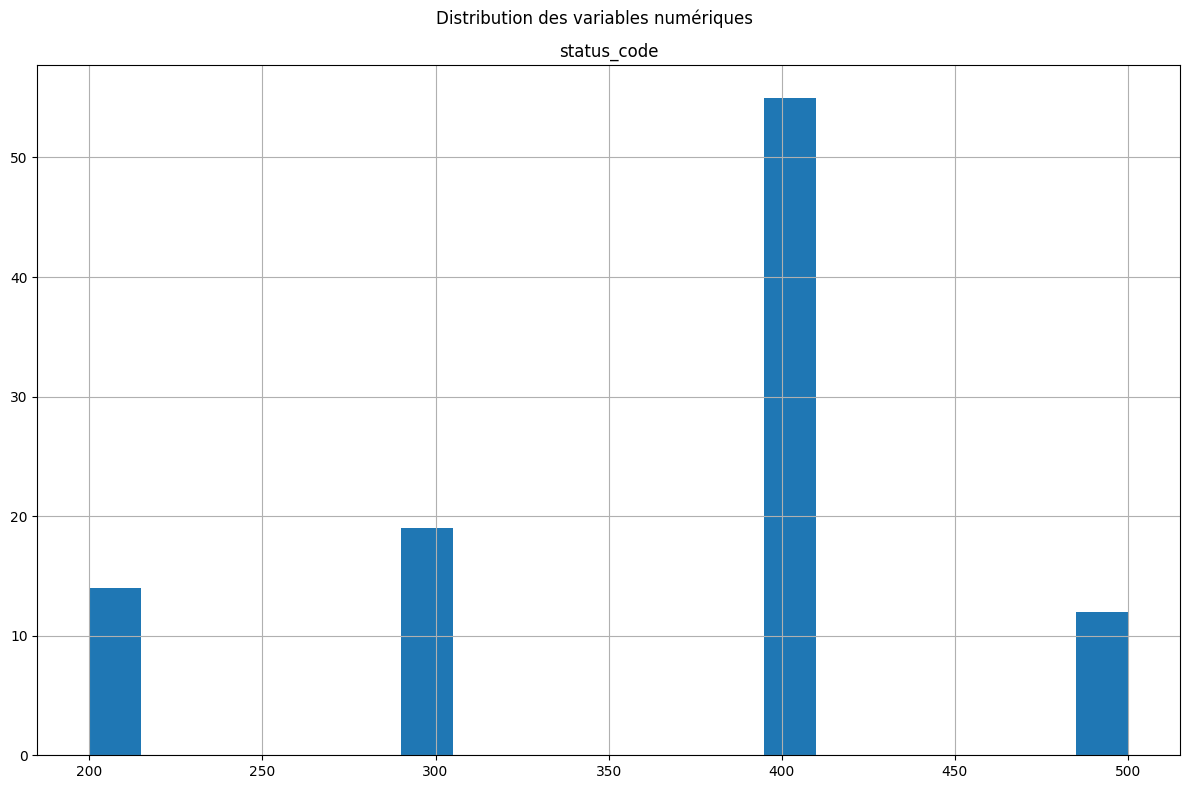

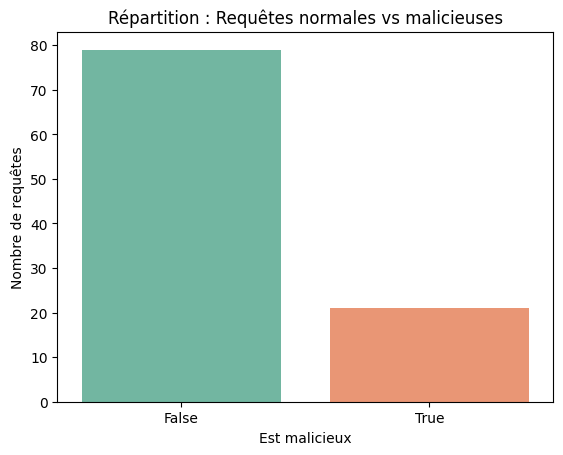

In [8]:
# Distribution des variables numériques
df.select_dtypes(include=[float, int]).hist(figsize=(12, 8), bins=20)
plt.suptitle('Distribution des variables numériques')
plt.tight_layout()
plt.show()

# Distribution requêtes normales vs malicieuses
sns.countplot(x='is_malicious', data=df, palette='Set2')
plt.title('Répartition : Requêtes normales vs malicieuses')
plt.xlabel('Est malicieux')
plt.ylabel('Nombre de requêtes')
plt.show()


## 6. Enregistrer les résultats
Enregistrer les résultats de l'analyse ou les données nettoyées dans un nouveau fichier.

## 7. Extraction de caractéristiques (feature engineering)
Pour la détection d'attaques web, il est important d'extraire des caractéristiques pertinentes des requêtes HTTP. Voici quelques exemples :
- Longueur de l'URL
- Nombre de paramètres
- Présence de caractères ou mots-clés suspects (ex : SELECT, UNION, <script>, ../, OR 1=1)
- Structure de la requête
- Fréquence de certains caractères spéciaux

In [9]:
# Feature engineering automatisé
def extract_features(df):
    # Longueur du chemin de la requête
    df = df.copy()
    df['path_length'] = df['request_path'].apply(lambda x: len(str(x)))
    # Nombre de paramètres dans l'URL
    df['param_count'] = df['request_path'].apply(lambda x: str(x).count('&'))
    # Présence de mots-clés suspects
    keywords = ['select', 'union', 'script', '../', 'or 1=1', 'cmd.exe',
                'passwd', 'shell', 'upload', 'phpmyadmin', 'admin']
    for kw in keywords:
        col = f'has_{kw.replace("/", "slash").replace(".", "dot").replace(" ", "_")}'
        df[col] = df['request_path'].str.lower().apply(lambda x: int(kw in x))
    # Nombre de caractères spéciaux
    df['special_char_count'] = df['request_path'].apply(
        lambda x: len(re.findall(r'[;=(){}\[\]<>]', str(x))))
    # Méthode HTTP encodée
    for method in ['GET', 'POST', 'PUT', 'DELETE']:
        df[f'method_{method}'] = (df['request_method'] == method).astype(int)
    # Code statut encodé
    for code in [200, 301, 400, 401, 403, 404, 500]:
        df[f'status_{code}'] = (df['status_code'] == code).astype(int)
    # User agents suspects
    df['user_agent_sqlmap'] = df['user_agent'].str.contains('sqlmap', case=False, na=False).astype(int)
    df['user_agent_nikto'] = df['user_agent'].str.contains('nikto', case=False, na=False).astype(int)
    df['user_agent_curl'] = df['user_agent'].str.contains('curl', case=False, na=False).astype(int)
    df['user_agent_python'] = df['user_agent'].str.contains('python', case=False, na=False).astype(int)
    return df

df = extract_features(df)
print(f"Features extraites : {df.shape[1]} colonnes")
df.head()


Features extraites : 36 colonnes


,timestamp,ip_address,request_method,request_path,status_code,user_agent,is_malicious,path_length,param_count,has_select,...,status_301,status_400,status_401,status_403,status_404,status_500,user_agent_sqlmap,user_agent_nikto,user_agent_curl,user_agent_python
0,2023-10-26 08:00:00,10.0.0.3,DELETE,/dashboard,500,Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/53...,False,10,0,0,...,0,0,0,0,0,1,0,0,0,0
1,2023-10-26 08:00:06,192.168.1.8,POST,"/admin/users.php?id=1%20UNION%20SELECT%20null,...",200,sqlmap/1.6.10 (http://sqlmap.org),True,67,0,1,...,0,0,0,0,0,0,1,0,0,0
2,2023-10-26 08:00:08,192.168.1.18,DELETE,/products,200,Nikto/2.1.6,False,9,0,0,...,0,0,0,0,0,0,0,1,0,0
3,2023-10-26 08:00:21,192.168.1.1,PUT,/products,200,Nikto/2.1.6,False,9,0,0,...,0,0,0,0,0,0,0,1,0,0
4,2023-10-26 08:00:32,192.168.1.9,DELETE,/shell.php,301,Mozilla/5.0 (Linux; Android 10) AppleWebKit/53...,True,10,0,0,...,1,0,0,0,0,0,0,0,0,0


## 8. Séparation des données et préparation pour le machine learning
On sépare les données en un ensemble d'entraînement et un ensemble de test, puis on prépare les variables explicatives (features) et la variable cible (label).

In [10]:
# Séparation des données et préparation pour le machine learning
from sklearn.model_selection import train_test_split

# Sélection des features (on enlève les colonnes non pertinentes)
features = [col for col in df.columns if col not in [
    'timestamp', 'ip_address', 'request_method', 'request_path', 'status_code', 'user_agent', 'is_malicious'
]]
X = df[features]
y = df['is_malicious']

# Séparation train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Taille train : {X_train.shape}, Taille test : {X_test.shape}")
print(f"Répartition des classes dans y_train :\n{y_train.value_counts(normalize=True)}")

Taille train : (80, 29), Taille test : (20, 29)
Répartition des classes dans y_train :
is_malicious
False    0.7875
True     0.2125
Name: proportion, dtype: float64


## 9. Entraînement et comparaison de plusieurs modèles de machine learning
On teste plusieurs algorithmes (régression logistique, forêt aléatoire, SVM, réseau de neurones) et on compare leurs performances.

=== Résultats des modèles ===
                     accuracy  precision  recall     f1
Neural Network            1.0        1.0     1.0  1.000
Logistic Regression       0.9        1.0     0.5  0.667
Random Forest             0.9        1.0     0.5  0.667
SVM                       0.9        1.0     0.5  0.667


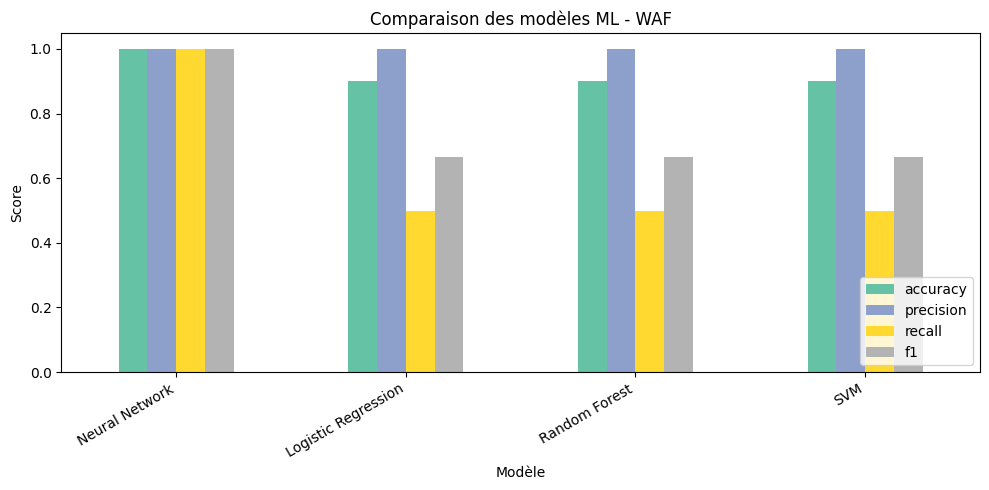

In [11]:
# Entraînement et comparaison de plusieurs modèles de machine learning
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42),
    'Neural Network': MLPClassifier(max_iter=500, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0)
    }

results_df = pd.DataFrame(results).T.sort_values('f1', ascending=False)
print("=== Résultats des modèles ===")
print(results_df.round(3))

# Visualisation des performances
results_df.plot(kind='bar', figsize=(10, 5), colormap='Set2')
plt.title('Comparaison des modèles ML - WAF')
plt.xlabel('Modèle')
plt.ylabel('Score')
plt.xticks(rotation=30, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 10. Sélection du meilleur modèle et analyse des résultats
On sélectionne le modèle ayant les meilleures performances globales et on analyse les erreurs (matrice de confusion, faux positifs/faux négatifs).

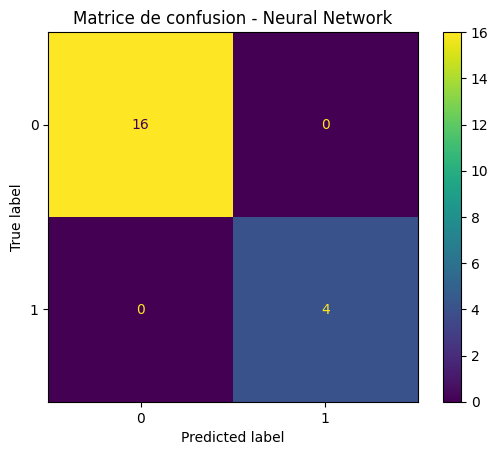

In [12]:
# Analyse du meilleur modèle : matrice de confusion
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# On suppose que le meilleur modèle est celui avec le meilleur F1-score
top_model_name = results_df['f1'].idxmax()
top_model = models[top_model_name]
y_pred = top_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title(f'Matrice de confusion - {top_model_name}')
plt.show()

## 11. Sauvegarde du modèle entraîné
On sauvegarde le modèle pour l'intégrer ensuite dans le prototype WAF (Flask).

In [13]:
# Sauvegarde du meilleur modèle entraîné
joblib.dump(top_model, 'waf_model.joblib')
print(f"Modèle sauvegardé : 'waf_model.joblib' ({top_model_name})")


Modèle sauvegardé : 'waf_model.joblib' (Neural Network)


## 12. Discussion, limites et perspectives
- Analyse des résultats obtenus
- Discussion sur les limites du modèle (généralisation, biais, attaques zero-day)
- Propositions d'améliorations (deep learning, détection d'anomalies, intégration SIEM)

Ce notebook fournit une base solide et structurée pour viser l'excellence dans votre projet de détection d'attaques web par machine learning.

In [14]:
# Enregistrer les données nettoyées dans un nouveau fichier CSV
df.to_csv('donnees_nettoyees.csv', index=False)